In [2]:
import pickle

pkl_file_path = "/home/uynk/Belgeler/Analyze_Projects/AliBaba_GenAI_Dataset/dataframes.pkl"

with open(pkl_file_path, 'rb') as file:
    dataframes = pickle.load(file)

### **<span style="color:orange"> Queue rt & size Distributions</span>**

queue_size_raw_anon: value=0 and pod=NaN are observed. This means the request has not yet departed from the Internal Load Balancer to a Pod. When requests are kept waiting in the waiting room (queue), they have not yet been assigned to a pod, which is why their container_ip values appear as NaN. When requests are dispatched, if a suitable pod cannot be found in the Endpoints list in accordance with the relevant microservices, the requests are held in the message queue. Thanks to KEDA, the HPA (Horizontal Pod Autoscaler) is triggered, and the Cloud system works to create a new pod and add it to the Endpoints list. The moment KEDA sees even 1 request in the queue, it immediately triggers the HPA to spin up a new pod in the Cloud system. For this reason, it is normal for the value to appear as 0 at the times measurements are taken.

queue_rt_raw_anon: Shows how much time a request spends in the queue between the moment it enters the Message Queue and the moment it is finally accepted by a pod and begins being processed on the GPU. In other words, it represents the pure waiting time the requests spend in the queue.

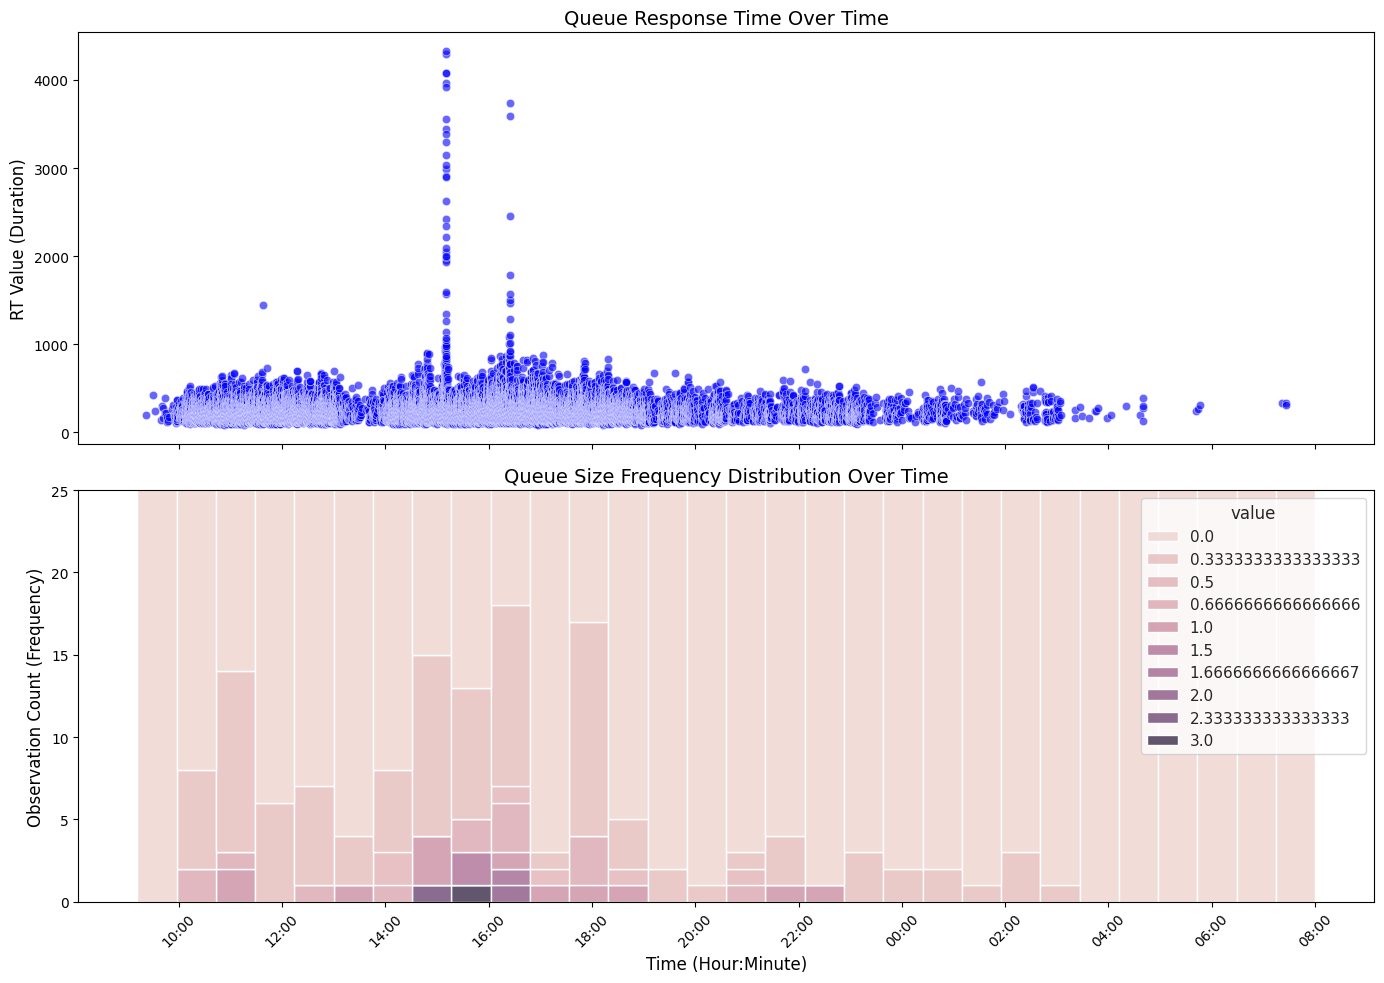

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Data Loading and Preprocessing
df_size = dataframes["queue_size_raw_anon.csv"]
df_rt = dataframes["queue_rt_raw_anon.csv"]

df_size['real_time_CST'] = pd.to_datetime(df_size['real_time_CST'])
df_rt['real_time_CST'] = pd.to_datetime(df_rt['real_time_CST'])

# 2. Create Figure for Two Subplots (Stacked)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
sns.set_theme(style="whitegrid")

# --- TOP PLOT: Response Time (Scatter Plot) ---
sns.scatterplot(data=df_rt, x="real_time_CST", y="value", ax=ax1, color='blue', alpha=0.6)
ax1.set_title('Queue Response Time Over Time', fontsize=14)
ax1.set_ylabel('RT Value (Duration)', fontsize=12)

# --- BOTTOM PLOT: Queue Size (Histogram) ---
sns.histplot(data=df_size, x='real_time_CST', hue='value', multiple='stack', bins=30, ax=ax2)
ax2.set_title('Queue Size Frequency Distribution Over Time', fontsize=14)
ax2.set_ylabel('Observation Count (Frequency)', fontsize=12)
ax2.set_xlabel('Time (Hour:Minute)', fontsize=12)
ax2.set_ylim(0, 25) # The limit you specified

# 3. Time Format Adjustments (For Bottom Plot Axis)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2)) 

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

`Graph interpretation:` This graph shows the time periods when bottlenecks occurred. Between 2022-09-11 and 2022-09-12, the RT graph shows the time from when requests leave the Internal Load Balancer until they reach the pods, and the Size graph shows a particular surge or interruption around 15:00 and 16:00.

- ### **<span style="color:orange"> (Queue_rt) Detection of container_ips and time zones that produce output with a delay exceeding 1000 ms</span>**

In [4]:
df = dataframes["queue_rt_raw_anon.csv"]
df['real_time_CST'] = pd.to_datetime(df['real_time_CST'])

outliers_df = df[df['value'] > 1000].copy()

outliers_df['time_str'] = outliers_df['real_time_CST'].dt.strftime('%H:%M:%S') 

pivot_result = pd.pivot_table(
    data=outliers_df, 
    values='value',        # The actual data to be displayed in the cells of the table
    index='container_ip',  # IP addresses will be in the rows
    columns='time_str',    # The times when outliers occurred will be in the columns
    aggfunc='max'          # If there are multiple values within the same minute, take the maximum (max)
)

pivot_result = pivot_result.fillna('-') 
display(pivot_result.head()) 
print(f"There are {len(pivot_result)} unique pods with a queue waiting time over 1000 ms, which are considered potential bottlenecks.")

time_str,11:38:18,15:11:06,16:24:15,16:25:12
container_ip,,,,
0e1eea513e63bd1b3648013b6623ff0c,-,2004.0,-,-
0e1fe71a611f28739fe7fc6915583da0,-,1065.0,-,-
25da09a77268ccc99a7968b3e453b8f0,-,4329.0,-,-
31408984596c7411b56cfc43d280bc02,-,2630.0,-,-
315a3a55de541f70b9f3d816692ac9a2,-,3448.0,-,-


There are 40 unique pods with a queue waiting time over 1000 ms, which are considered potential bottlenecks.


- ### **<span style="color:orange">(Queue_size)Average queue lengths in detected time periods</span>**

In [4]:
df = dataframes["queue_size_raw_anon.csv"] 
mask = df["real_time_CST"].dt.strftime('%H:%M:%S').isin(pivot_result.columns)

result_df = df[mask]
result_df[["value","container_ip","real_time_CST"]] 

,value,container_ip,real_time_CST
154,0.000000,NaN,2022-09-11 11:38:18
376,2.333333,NaN,2022-09-11 15:11:06
452,1.666667,NaN,2022-09-11 16:24:15
453,0.333333,NaN,2022-09-11 16:25:12


- ### **<span style="color:orange">Are the pods suspected of having high density or interruptions also found in other datasets?</span>**

In [5]:
########## Checking if the pods I suspect of experiencing bottlenecks at specific times (11:38:18, 15:11:06, 16:24:15, 16:25:12) exist in other datasets
problematic_ips = set(pivot_result.index)
found_matches = {}

print("Scanning datasets...\n")

for df_name, df_obj in dataframes.items():
    if df_name == "queue_rt_raw_anon.csv":
        continue
        
    if "container_ip" in df_obj.columns:
        current_ips = set(df_obj["container_ip"].unique())
        matched_ips = problematic_ips.intersection(current_ips)
        
        if matched_ips:
            found_matches[df_name] = list(matched_ips)
            print(f"Found {len(matched_ips)} matching pods in the '{df_name}' dataset.")

Scanning datasets...

Found 40 matching pods in the 'pipeline_inference_data_anon.csv' dataset.
Found 40 matching pods in the 'controlnet_latency_data_anon.csv' dataset.
Found 40 matching pods in the 'lora_update_latency_anon.csv' dataset.
Found 40 matching pods in the 'pod_memory_util_anon.csv' dataset.
Found 40 matching pods in the 'model_predict_data_anon.csv' dataset.
Found 40 matching pods in the 'pod_gpu_duty_cycle_anon.csv' dataset.
Found 40 matching pods in the 'pipeline_update_latency_anon.csv' dataset.
Found 40 matching pods in the 'qps.csv' dataset.
Found 40 matching pods in the 'pod_gpu_memory_used_bytes_anon.csv' dataset.
Found 40 matching pods in the 'basemodel_update_latency_anon.csv' dataset.


`interpretation:` Bu aşamada özellikle Queue_rt verisine yani podların bekleme sürelerine odaklandım. Bunun sebebi, sistemde daha önce hiç pod oluşturulmamış isteklere uygun yeni podlar oluşturulacağı zaman, isteklerin kuyruk boyutunu artırabilir. Bu sebeple kuyruk size değeri zaman zaman artabilir. 